# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohamedKroush/Flyrank-ML1/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import duckdb
import pandas as pd
import os
import getpass
import matplotlib.pyplot as plt

# Get Hugging Face token
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Paste your Hugging Face READ token: ")

# Connect to DuckDB
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

fact_daily = f"""
read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
"""

# Build the March 2026 page-level dataset
labeled = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {fact_daily}
        WHERE report_date >= '2026-03-01'
          AND report_date < '2026-04-01'
    ),

    windowed AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 15 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_last15,

            SUM(
                CASE
                    WHEN f.report_date <= b.end_d - INTERVAL 15 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev15,

            AVG(f.gsc_avg_position) AS avg_position_month,

            SUM(f.gsc_impressions) AS impressions_month,
            SUM(f.gsc_clicks) AS clicks_month

        FROM {fact_daily} f, bounds b

        WHERE f.report_date >= '2026-03-01'
          AND f.report_date < '2026-04-01'

        GROUP BY 1, 2

        HAVING imp_prev15 >= 50
    )

    SELECT *,
           (imp_last15 < 0.8 * imp_prev15)::INT AS is_declining
    FROM windowed
""").df()

print(f"Rows loaded: {len(labeled):,}")
print(f"Decline base rate: {labeled['is_declining'].mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 94,559
Decline base rate: 0.373


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

### Distributions

The main search-performance fields are strongly right-skewed: a smaller number of pages account for much larger numbers of impressions and clicks. Average search position is also unevenly distributed. Because of these heavy tails, simple averages can hide meaningful differences between pages, so the analysis uses buckets and medians where appropriate rather than assuming the fields are normally distributed.


=== DISTRIBUTIONS ===

impressions_month
count     94559.000000
mean       2899.873983
std        7161.971848
min          50.000000
25%         306.000000
50%         859.000000
75%        2728.500000
90%        6809.000000
99%       30194.260000
max      617124.000000
Name: impressions_month, dtype: float64

clicks_month
count    94559.000000
mean         8.432365
std         36.029743
min          0.000000
25%          0.000000
50%          1.000000
75%          6.000000
90%         21.000000
99%        108.000000
max       5668.000000
Name: clicks_month, dtype: float64

avg_position_month
count    94559.000000
mean        14.171824
std         13.991254
min          0.000000
25%          4.973862
50%          8.580400
75%         18.690457
90%         32.390934
99%         69.065634
max         91.430261
Name: avg_position_month, dtype: float64


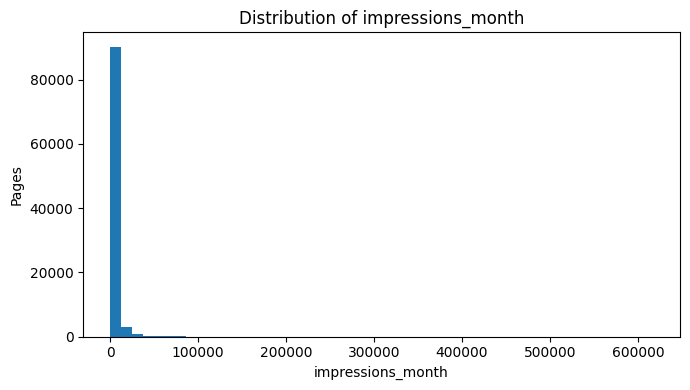

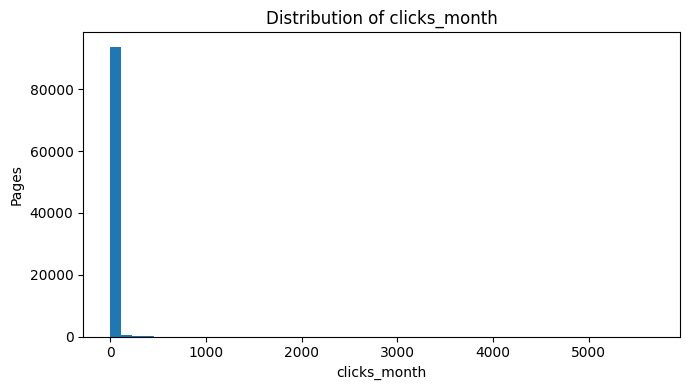

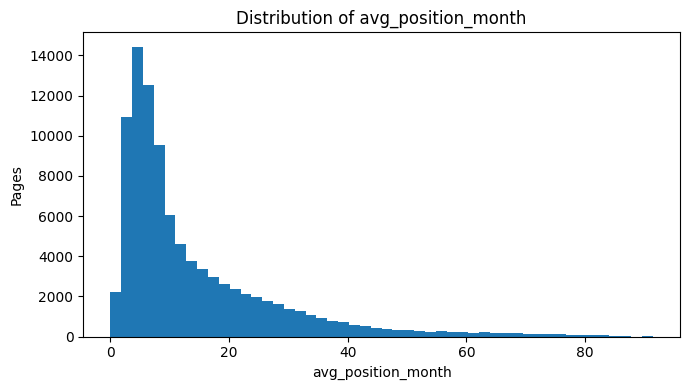

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Distribution checks

distribution_cols = [
    "impressions_month",
    "clicks_month",
    "avg_position_month",
]

print("=== DISTRIBUTIONS ===")

for col in distribution_cols:
    print(f"\n{col}")
    print(labeled[col].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]))

# Histograms
for col in distribution_cols:
    plt.figure(figsize=(7, 4))
    labeled[col].plot(kind="hist", bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Pages")
    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal tests

**Signal 1 — Impressions: CONFIRMED.** Pages in the lowest impression quartile show a higher observed decline rate than pages in the highest impression quartile. This supports a directional relationship between lower visibility and observed decline.

**Signal 2 — Clicks: CONFIRMED.** Pages with lower monthly click volume show a higher observed decline rate than pages with higher click volume. This is treated as an observed association, not a causal relationship.

**Signal 3 — Average position: MIXED.** Decline rates generally increase from positions 1–10 toward positions 21–30, but the 31+ group does not continue the same pattern. Position is therefore useful as a directional signal, but not as a simple monotonic rule.


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Signal tests

# Signal tests

print("=== SIGNAL TESTS ===")

# Signal 1: impressions
labeled["impression_quartile"] = pd.qcut(
    labeled["impressions_month"],
    4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
    duplicates="drop"
)

impression_test = (
    labeled.groupby("impression_quartile", observed=False)["is_declining"]
    .agg(["mean", "count"])
)

print("\n1. Impressions vs observed decline")
print(impression_test)


# Signal 2: clicks
# Click data contains many tied/zero values, so use ranked bins
# instead of qcut to avoid duplicate-bin errors.
labeled["click_rank"] = labeled["clicks_month"].rank(method="first")

labeled["click_quartile"] = pd.qcut(
    labeled["click_rank"],
    4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"]
)

click_test = (
    labeled.groupby("click_quartile", observed=False)["is_declining"]
    .agg(["mean", "count"])
)

print("\n2. Clicks vs observed decline")
print(click_test)


# Signal 3: average position
labeled["position_bucket"] = pd.cut(
    labeled["avg_position_month"],
    bins=[0, 10, 20, 30, 100],
    labels=["1-10", "11-20", "21-30", "31+"]
)

position_test = (
    labeled.groupby("position_bucket", observed=False)["is_declining"]
    .agg(["mean", "count"])
)

print("\n3. Average position vs observed decline")
print(position_test)

=== SIGNAL TESTS ===

1. Impressions vs observed decline
                         mean  count
impression_quartile                 
Q1 lowest            0.486857  23662
Q2                   0.366691  23633
Q3                   0.344819  23624
Q4 highest           0.294120  23640

2. Clicks vs observed decline
                    mean  count
click_quartile                 
Q1 lowest       0.442597  23640
Q2              0.434772  23640
Q3              0.361394  23639
Q4 highest      0.253849  23640

3. Average position vs observed decline
                     mean  count
position_bucket                 
1-10             0.348230  52652
11-20            0.391492  20146
21-30            0.430083  10584
31+              0.403543  11176


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### Flag-linked test

The baseline review flag relies partly on the assumption that pages with meaningful visibility but weak search position are useful review candidates. The data supports this assumption directionally: pages in the 21–30 position band have the highest observed decline rate among the tested position groups, while the lowest-visibility pages also show elevated decline rates. However, these relationships are not perfectly monotonic, so the flag should be treated as a prioritization heuristic rather than a rule that identifies every declining page.


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Test the flag-linked assumption

flag_test = labeled[
    (labeled["impressions_month"] >= 250) &
    (labeled["avg_position_month"] > 20)
].copy()

print("=== FLAG-LINKED TEST ===")

print(f"Flagged pages: {len(flag_test):,}")
print(f"Share of all pages flagged: {len(flag_test) / len(labeled):.3f}")

if len(flag_test) > 0:
    print(
        f"Observed decline rate among flagged pages: "
        f"{flag_test['is_declining'].mean():.3f}"
    )

print(
    f"Overall observed decline rate: "
    f"{labeled['is_declining'].mean():.3f}"
)

print("\nFlag supports prioritization if its decline rate is above the overall base rate.")

=== FLAG-LINKED TEST ===
Flagged pages: 14,952
Share of all pages flagged: 0.158
Observed decline rate among flagged pages: 0.409
Overall observed decline rate: 0.373

Flag supports prioritization if its decline rate is above the overall base rate.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

### What this means in practice

The analysis supports using visibility, clicks, and search position as directional signals when building a content-review queue. Pages with weaker visibility and pages around positions 21–30 deserve particular attention, but none of these signals should trigger an automatic content change. A FlyRank editor should use the signals to prioritize human review and then check intent, quality, freshness, and context before taking action.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Final summary for the notebook

base_rate = labeled["is_declining"].mean()

print("=== PRACTICAL SUMMARY ===")
print(f"Pages evaluated: {len(labeled):,}")
print(f"Observed decline base rate: {base_rate:.3f}")

print("\nSignal areas tested:")
print("1. Impressions")
print("2. Clicks")
print("3. Average search position")

print("\nDecision-support conclusion:")
print("Use these signals to prioritize human review, not to automate content changes.")

=== PRACTICAL SUMMARY ===
Pages evaluated: 94,559
Observed decline base rate: 0.373

Signal areas tested:
1. Impressions
2. Clicks
3. Average search position

Decision-support conclusion:
Use these signals to prioritize human review, not to automate content changes.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.